In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
base = "Dino"
threshold = 3.5

In [3]:
Comparison = pd.read_csv(f"GT Base Output/DetectionComparison.csv")
if base == "GT":
    sec = "Dino"
if base == "Dino":
    sec = "GT"

In [4]:
M_comp = Comparison.to_numpy()
t_vec = defaultdict(list)

for t in M_comp:
    t_vec[t[1]].append(t)

for t_val in t_vec:
    t_vec[t_val] = np.array(t_vec[t_val]) 

t_list = np.zeros((len(t_vec),3), dtype=object)

In [5]:
for i, t in enumerate(t_vec):
    t_val = t_vec[t]
    counts = len((t_val[:,9]))
    true_counts = (np.sum(t_val[:,9] < threshold))
    t_list[i][0] = int(t)
    t_list[i][1] = counts
    t_list[i][2] = true_counts

FileNotFoundError: [Errno 2] No such file or directory: 'Base Plots/CME vs Dino Match by Time Point.png'

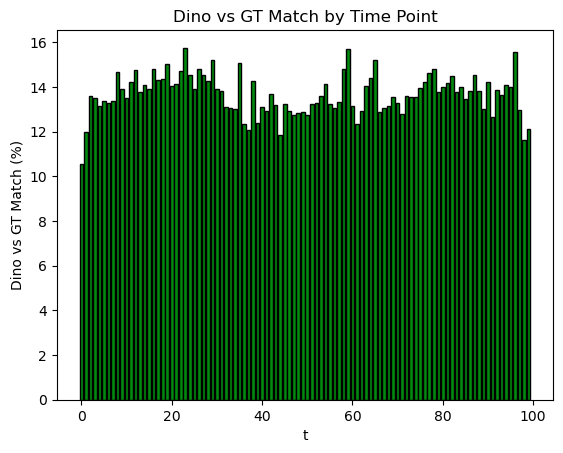

In [6]:
plt.bar(t_list[:,0], 100*t_list[:,2]/t_list[:,1], color="#028A0F", edgecolor = "black")
plt.xlabel("t")
plt.ylabel(f"{base} vs {sec} Match (%)")
plt.title(f"{base} vs {sec} Match by Time Point")
plt.savefig(f"Base Plots/CME vs Dino Match by Time Point.png")
plt.show()


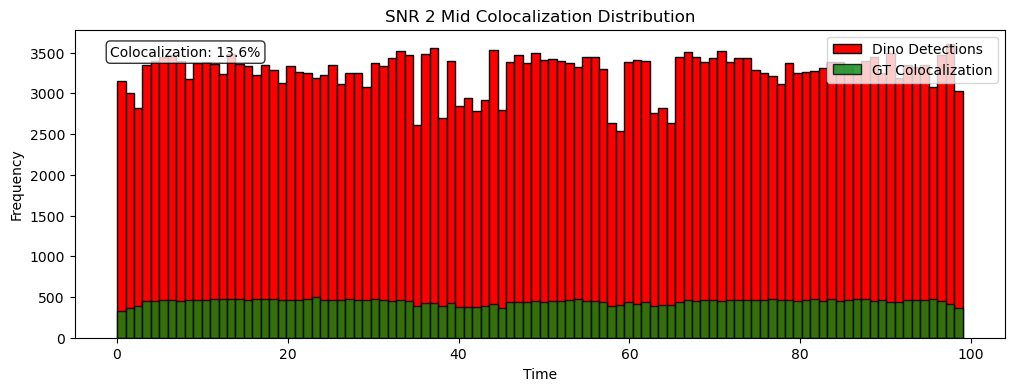

In [7]:
Comp_SNR = Comparison.copy()
Comp_SNR_coloc = Comp_SNR[Comp_SNR["Distance"] < threshold]

Colocalization = round(100 * len(Comp_SNR_coloc) / len(Comp_SNR), 1)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.hist(Comp_SNR["FI (CME)"], bins=100, color="red", label=f"{base} Detections", edgecolor="black")
ax.hist(Comp_SNR_coloc["FI (CME)"], bins=100, color="#028A0F", alpha=0.8, label=f"{sec} Colocalization", edgecolor="black")
ax.set_xlabel("Time")
ax.set_ylabel("Frequency")
ax.set_title("SNR 2 Mid Colocalization Distribution")
ax.legend()

# Lägg till textruta med colocalization-procent
ax.text(0.20, 0.95, f'Colocalization: {Colocalization}%', 
        transform=ax.transAxes, fontsize=10, 
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

plt.savefig("SNR2_mid_Dino.png")
plt.show()
